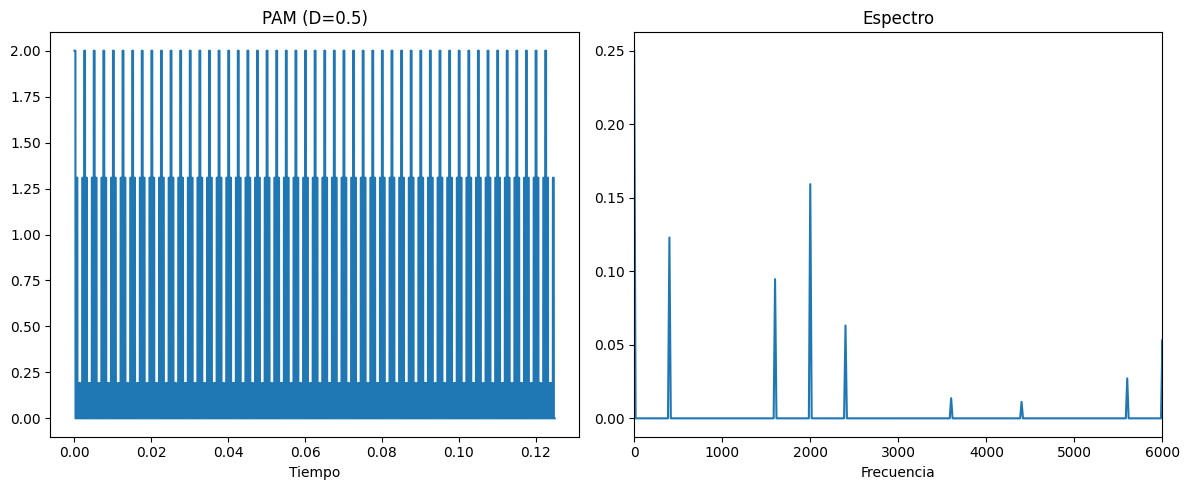

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parámetros
# =========================
Amax = 1

fin = 1e3
fport = 2 * fin
fm = 0.2 * fport

fs = 2e3          # frecuencia de muestreo
T = 1/fs

D = 0.5                  # duty cycle
Ts = D * T               # tiempo de hold

# tiempo (alta resolución)
t_total = 50 / fm
dt = T / 50
t = np.arange(0, t_total, dt)

# señal original
def x_cont(t):
    return Amax * (1 + np.cos(2*np.pi*fm*t)) * np.cos(2*np.pi*fport*t)

# =========================
# PAM (S&H + llave)
# =========================
x_out = np.zeros_like(t)

for n in range(int(t_total / T)):
    tn = n * T
    
    # valor muestreado
    x_n = x_cont(tn)
    
    # solo durante Ts vale x_n, luego 0
    idx = (t >= tn) & (t < tn + Ts)
    x_out[idx] = x_n

# =========================
# FFT
# =========================
window = np.hanning(len(x_out))

N = len(x_out)
Xf = np.fft.fft(x_out * window)
freq = np.fft.fftfreq(N, dt)

idx = freq >= 0
freq = freq[idx]
Xf = np.abs(Xf[idx]) / N

# =========================
# Gráficos
# =========================
plt.figure(figsize=(12,5))

# tiempo
plt.subplot(1,2,1)
plt.plot(t, x_out)
plt.title(f"PAM (D={D})")
plt.xlabel("Tiempo")

# frecuencia
plt.subplot(1,2,2)
plt.plot(freq, Xf)
plt.xlim(0, 3*fport)
plt.title("Espectro")
plt.xlabel("Frecuencia")

plt.tight_layout()
plt.show()

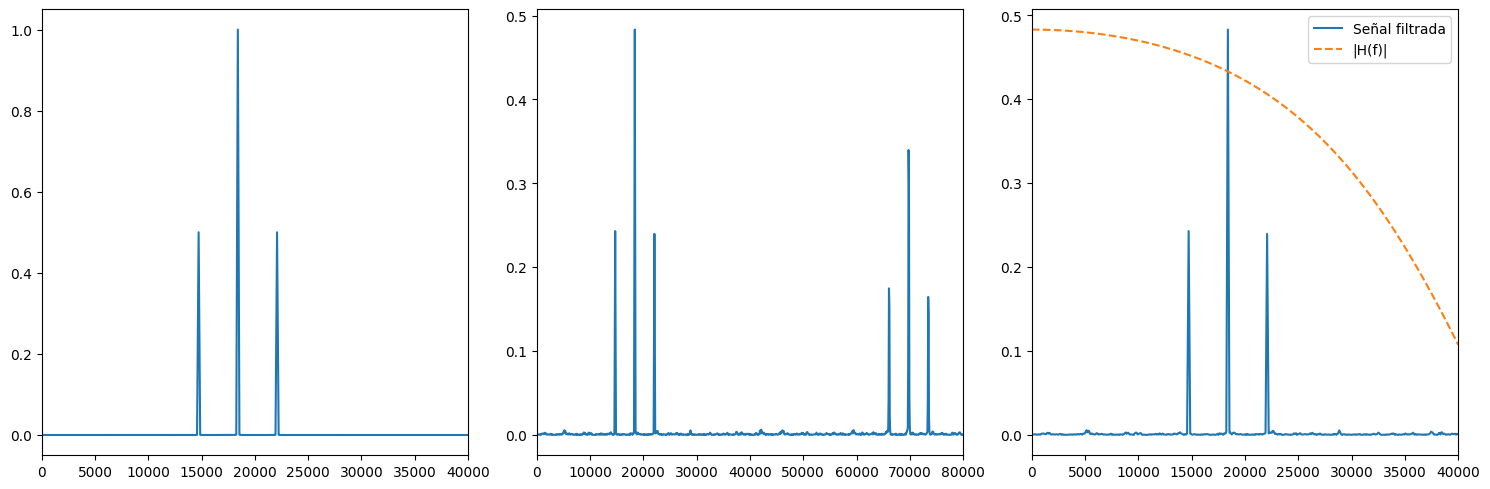

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cheby1, filtfilt, freqz
plt.close('all')
# =========================
# Parámetros
# =========================
Amax = 1

fin = 9.2e3
fport = 2 * fin
fm = 0.2 * fport

fs = 88.2e3
T = 1/fs

D = 0.5
Ts = D * T

# tiempo
t_total = 50 / fm
dt = T / 20
t = np.arange(0, t_total, dt)

# =========================
# Señal original
# =========================
def x_cont(t):
    return Amax * (1 + np.cos(2*np.pi*fm*t)) * np.cos(2*np.pi*fport*t)

x_original = x_cont(t)

# =========================
# PAM
# =========================
x_out = np.zeros_like(t)

for n in range(int(t_total / T)):
    tn = n * T
    x_n = x_cont(tn)
    idx = (t >= tn) & (t < tn + Ts)
    x_out[idx] = x_n

# =========================
# Filtro Chebyshev
# =========================
from scipy.signal import cheb1ord, cheby1, bilinear, freqz

# =========================
# Diseño analógico
# =========================
Ap = 1.5  # dB
Aa = 40   # dB

fp = 22.05e3
fa = 44.1e3

# prewarping (MUY importante)
wp = 2 * fs * np.tan(np.pi * fp / fs)
wa = 2 * fs * np.tan(np.pi * fa / fs)

# orden mínimo
N, Wn = cheb1ord(wp, wa, Ap, Aa, analog=True)

# filtro analógico
b_a, a_a = cheby1(N, Ap, Wn, btype='low', analog=True)

# =========================
# Transformación bilineal
# =========================
b, a = bilinear(b_a, a_a, fs)

# =========================
# Aplicar filtro digital
# =========================
x_rec = filtfilt(b, a, x_out)

# =========================
# Respuesta en frecuencia (digital)
# =========================
w, h = freqz(b, a, worN=4096, fs=fs)

# =========================
# FFT (CORREGIDA)
# =========================
def compute_fft(x, dt):
    N = len(x)
    
    window = np.hanning(N)
    X = np.fft.fft(x * window)
    
    # corrección de ventana + espectro unilateral
    X = np.abs(X) * 2 / (N * np.mean(window))
    
    f = np.fft.fftfreq(N, dt)
    idx = f >= 0
    
    return f[idx], X[idx]

f1, X1 = compute_fft(x_original, dt)
f2, X2 = compute_fft(x_out, dt)
f3, X3 = compute_fft(x_rec, dt)

# =========================
# Respuesta del filtro
# =========================
w, h = freqz(b, a, worN=4096, fs=fs)

# =========================
# GRÁFICOS
# =========================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(f1, X1)
plt.xlim(0, 40e3)

plt.subplot(1,3,2)
plt.plot(f2, X2)
plt.xlim(0, 80e3)

plt.subplot(1,3,3)
plt.plot(f3, X3, label="Señal filtrada")
plt.plot(w, np.abs(h)*np.max(X3), '--', label="|H(f)|")
plt.xlim(0, 40e3)
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# EXPORTAR PDFs
# =========================

# Original
plt.figure()
plt.plot(f1, X1)
plt.xlim(0, 40e3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.tight_layout()
plt.close()

# PAM
plt.figure()
plt.plot(f2, X2)
plt.xlim(0, 80e3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.tight_layout()
plt.savefig("espectro_pam.pdf")
plt.close()

# Filtrada + filtro
plt.figure()
plt.plot(f3, X3, label="Señal filtrada")
plt.xlim(0, 40e3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("espectro_filtrado.pdf")
plt.close()

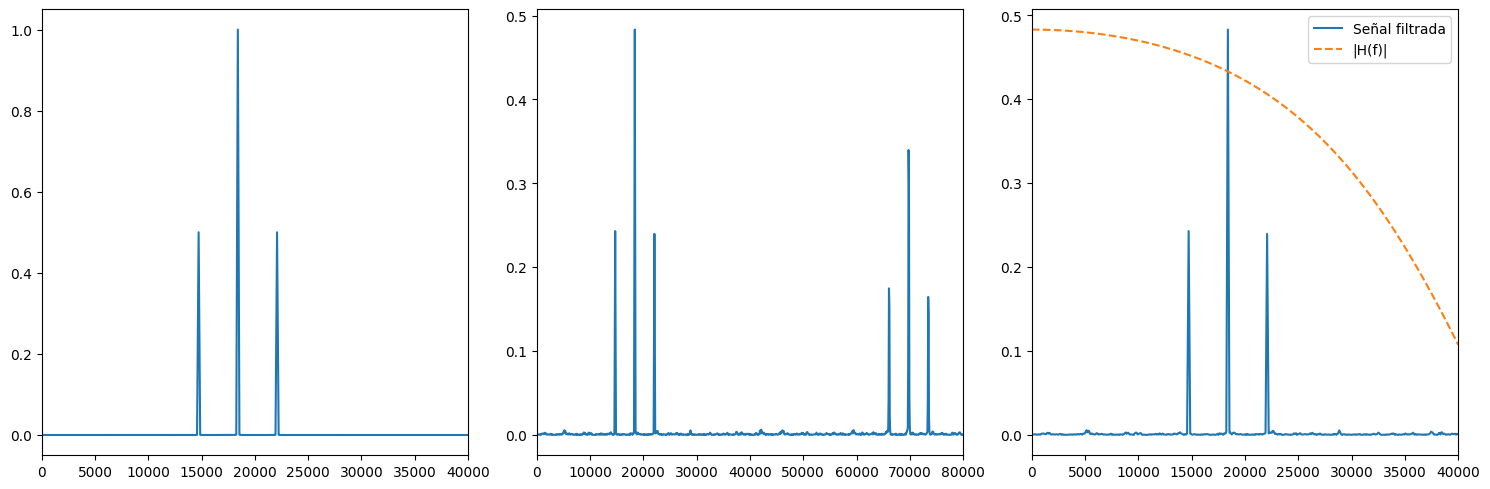

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cheby1, filtfilt, freqz
plt.close('all')
# =========================
# Parámetros
# =========================
Amax = 1

fin = 9.2e3
fport = 2 * fin
fm = 0.2 * fport

fs = 88.2e3
T = 1/fs

D = 0.5
Ts = D * T

# tiempo
t_total = 50 / fm
dt = T / 20
t = np.arange(0, t_total, dt)

# =========================
# Señal original
# =========================
def x_cont(t):
    return Amax * (1 + np.cos(2*np.pi*fm*t)) * np.cos(2*np.pi*fport*t)

x_original = x_cont(t)

# =========================
# PAM
# =========================
x_out = np.zeros_like(t)

for n in range(int(t_total / T)):
    tn = n * T
    x_n = x_cont(tn)
    idx = (t >= tn) & (t < tn + Ts)
    x_out[idx] = x_n

# =========================
# Filtro Chebyshev
# =========================
from scipy.signal import cheb1ord, cheby1, bilinear, freqz

# =========================
# Diseño analógico
# =========================
Ap = 1.5  # dB
Aa = 40   # dB

fp = 22.05e3
fa = 44.1e3

# prewarping (MUY importante)
wp = 2 * fs * np.tan(np.pi * fp / fs)
wa = 2 * fs * np.tan(np.pi * fa / fs)

# orden mínimo
N, Wn = cheb1ord(wp, wa, Ap, Aa, analog=True)

# filtro analógico
b_a, a_a = cheby1(N, Ap, Wn, btype='low', analog=True)

# =========================
# Transformación bilineal
# =========================
b, a = bilinear(b_a, a_a, fs)

# =========================
# Aplicar filtro digital
# =========================
x_rec = filtfilt(b, a, x_out)

# =========================
# Respuesta en frecuencia (digital)
# =========================
w, h = freqz(b, a, worN=4096, fs=fs)

# =========================
# FFT (CORREGIDA)
# =========================
def compute_fft(x, dt):
    N = len(x)
    
    window = np.hanning(N)
    X = np.fft.fft(x * window)
    
    # corrección de ventana + espectro unilateral
    X = np.abs(X) * 2 / (N * np.mean(window))
    
    f = np.fft.fftfreq(N, dt)
    idx = f >= 0
    
    return f[idx], X[idx]

f1, X1 = compute_fft(x_original, dt)
f2, X2 = compute_fft(x_out, dt)
f3, X3 = compute_fft(x_rec, dt)

# =========================
# Respuesta del filtro
# =========================
w, h = freqz(b, a, worN=4096, fs=fs)

# =========================
# GRÁFICOS
# =========================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(f1, X1)
plt.xlim(0, 40e3)

plt.subplot(1,3,2)
plt.plot(f2, X2)
plt.xlim(0, 80e3)

plt.subplot(1,3,3)
plt.plot(f3, X3, label="Señal filtrada")
plt.plot(w, np.abs(h)*np.max(X3), '--', label="|H(f)|")
plt.xlim(0, 40e3)
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# EXPORTAR PDFs
# =========================

# Original
plt.figure()
plt.plot(f1, X1)
plt.xlim(0, 40e3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.tight_layout()
plt.close()

# PAM
plt.figure()
plt.plot(f2, X2)
plt.xlim(0, 80e3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid()
plt.tight_layout()
plt.close()

# Filtrada + filtro
plt.figure()
plt.plot(f3, X3, label="Señal filtrada")
plt.xlim(0, 40e3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("espectro_filtrado.pdf")
plt.close()